# Week 3 Project — Python & Data Wrangling
**Task:** Clean a messy dataset in Pandas — handle missing values, filter rows, create new columns.

Dataset: a fitness log (`Duration`, `Date`, `Pulse`, `Maxpulse`, `Calories`) for December 2020.

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")
df.head(10)

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0
5,60,'2020/12/06',102,127,300.0
6,60,'2020/12/07',110,136,374.0
7,450,'2020/12/08',104,134,253.3
8,30,'2020/12/09',109,133,195.1
9,60,'2020/12/10',98,124,269.0


## 2. Explore the Mess
Before cleaning anything, check data types and missing values to see what needs fixing.

In [2]:
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Duration      int64
Date            str
Pulse         int64
Maxpulse      int64
Calories    float64
dtype: object

Missing values per column:
Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

Duplicate rows: 1


**Issues found:**
- `Date` is stored as text, wrapped in stray quotes (`'2020/12/01'`), one row is a plain int (`20201226`), and one row is empty.
- `Duration` has an outlier (`450`) that's almost certainly a typo for `45`.
- `Calories` has 2 missing values.
- Row 12 is an exact duplicate of row 11 (`2020/12/12`).

## 3. Fix the `Date` Column

In [3]:
# Strip stray single-quotes, fix the one row stored as a bare int, then parse to real dates
df["Date"] = df["Date"].astype(str).str.replace("'", "", regex=False)
df.loc[df["Date"] == "nan", "Date"] = np.nan
df["Date"] = df["Date"].str.replace("20201226", "2020/12/26", regex=False)
df["Date"] = pd.to_datetime(df["Date"], format="%Y/%m/%d", errors="coerce")

# The one row with a genuinely missing date can't be recovered, so drop it
df = df.dropna(subset=["Date"])
df["Date"].head()

0   2020-12-01
1   2020-12-02
2   2020-12-03
3   2020-12-04
4   2020-12-05
Name: Date, dtype: datetime64[us]

## 4. Fix Wrong Data

In [4]:
# A Duration of 450 minutes (7.5 hours) doesn't fit this dataset -> treat as a typo for 45
df.loc[df["Duration"] > 120, "Duration"] = 45
df["Duration"].describe()

count    31.000000
mean     56.129032
std       7.714670
min      30.000000
25%      60.000000
50%      60.000000
75%      60.000000
max      60.000000
Name: Duration, dtype: float64

## 5. Handle Missing Values

In [5]:
# Fill missing Calories with the column mean
df["Calories"] = df["Calories"].fillna(round(df["Calories"].mean(), 1))
df["Calories"].isna().sum()

np.int64(0)

## 6. Remove Duplicate Rows

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

## 7. Create New Columns
- `Calories_per_Minute` — efficiency of the workout
- `Pulse_Range` — Maxpulse − Pulse
- `Intensity` — Low / Moderate / High, based on Pulse

In [7]:
df["Calories_per_Minute"] = round(df["Calories"] / df["Duration"], 2)
df["Pulse_Range"] = df["Maxpulse"] - df["Pulse"]
df["Intensity"] = pd.cut(df["Pulse"], bins=[0, 100, 115, 200], labels=["Low", "Moderate", "High"])
df.head(10)

,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Range,Intensity
0,60,2020-12-01,110,130,409.1,6.82,20,Moderate
1,60,2020-12-02,117,145,479.0,7.98,28,High
2,60,2020-12-03,103,135,340.0,5.67,32,Moderate
3,45,2020-12-04,109,175,282.4,6.28,66,Moderate
4,45,2020-12-05,117,148,406.0,9.02,31,High
5,60,2020-12-06,102,127,300.0,5.00,25,Moderate
6,60,2020-12-07,110,136,374.0,6.23,26,Moderate
7,45,2020-12-08,104,134,253.3,5.63,30,Moderate
8,30,2020-12-09,109,133,195.1,6.50,24,Moderate
9,60,2020-12-10,98,124,269.0,4.48,26,Low


## 8. Filter Rows
Example: isolate "high effort" workouts where Calories burned exceeds 300.

In [8]:
high_effort = df[df["Calories"] > 300]
print(f"{len(high_effort)} of {len(df)} workouts burned over 300 calories")
high_effort.head()

14 of 30 workouts burned over 300 calories


,Duration,Date,Pulse,Maxpulse,Calories,Calories_per_Minute,Pulse_Range,Intensity
0,60,2020-12-01,110,130,409.1,6.82,20,Moderate
1,60,2020-12-02,117,145,479.0,7.98,28,High
2,60,2020-12-03,103,135,340.0,5.67,32,Moderate
4,45,2020-12-05,117,148,406.0,9.02,31,High
6,60,2020-12-07,110,136,374.0,6.23,26,Moderate


## 9. Save the Cleaned Data

In [9]:
df.to_csv("data_cleaned.csv", index=False)
high_effort.to_csv("high_effort_workouts.csv", index=False)
print("Saved data_cleaned.csv and high_effort_workouts.csv")

Saved data_cleaned.csv and high_effort_workouts.csv


## 10. Visualize (Matplotlib & Seaborn)

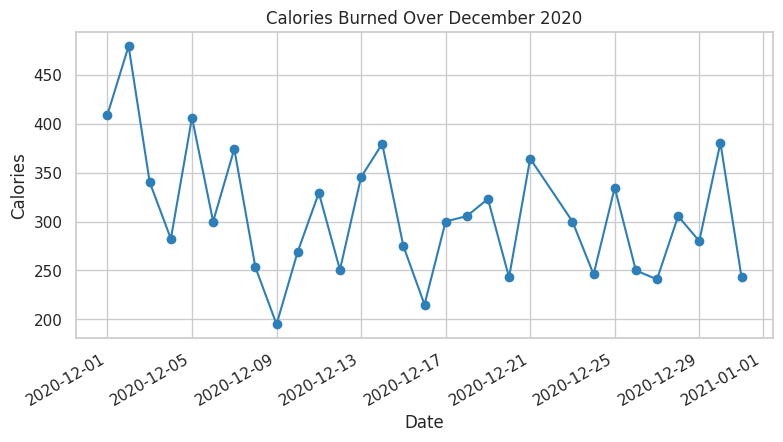

In [10]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(df["Date"], df["Calories"], marker="o", color="#2c7fb8")
ax.set_title("Calories Burned Over December 2020")
ax.set_xlabel("Date"); ax.set_ylabel("Calories")
fig.autofmt_xdate()
plt.show()

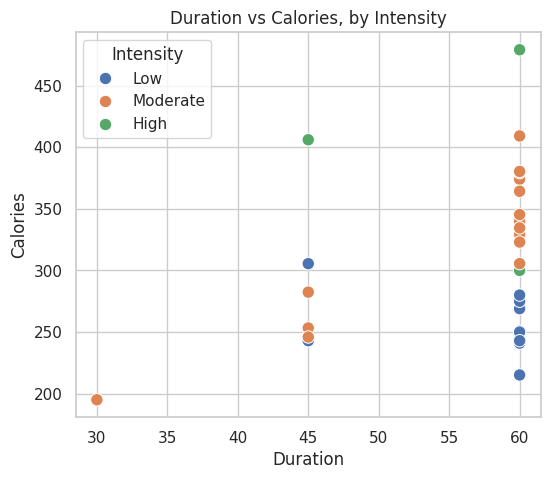

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x="Duration", y="Calories", hue="Intensity", s=80, ax=ax)
ax.set_title("Duration vs Calories, by Intensity")
plt.show()

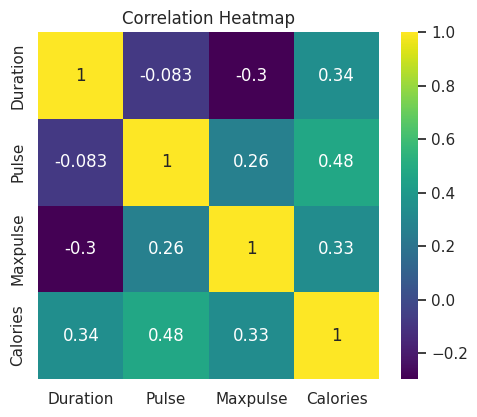

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
corr = df[["Duration", "Pulse", "Maxpulse", "Calories"]].corr()
sns.heatmap(corr, annot=True, cmap="viridis", ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

## Summary
- Parsed and standardized the `Date` column (fixed quoted strings, an int-typed date, and one missing date).
- Corrected an outlier in `Duration` (450 → 45).
- Filled missing `Calories` values with the column mean.
- Removed 1 exact duplicate row.
- Added `Calories_per_Minute`, `Pulse_Range`, and `Intensity` columns.
- Filtered out the high-effort workouts (Calories > 300).
- Visualized trends with Matplotlib and Seaborn.